<a href="https://colab.research.google.com/github/Asigen93/Measurement-Report-Skripsi/blob/main/Gabungan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Buat measurement Report.xlsx to Buat measurement Report (1).xlsx


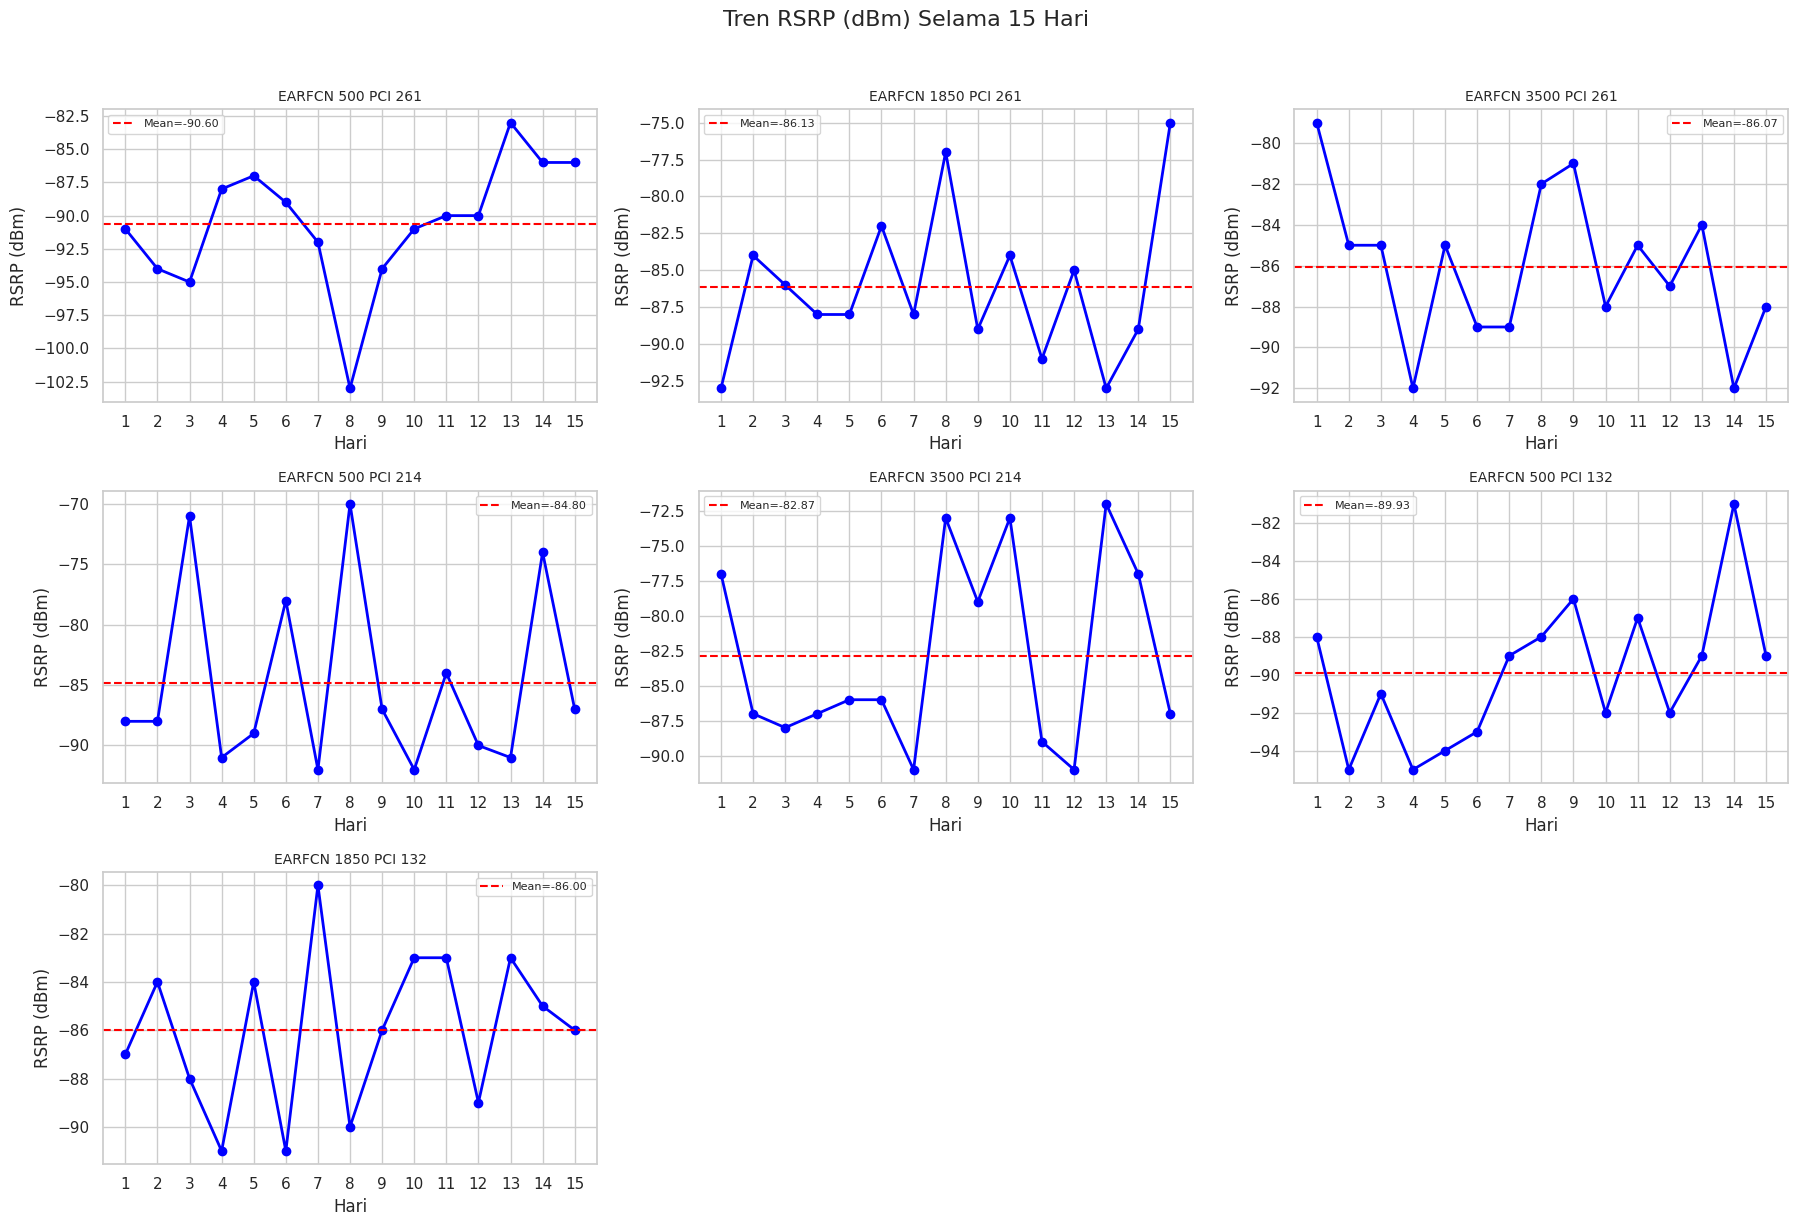

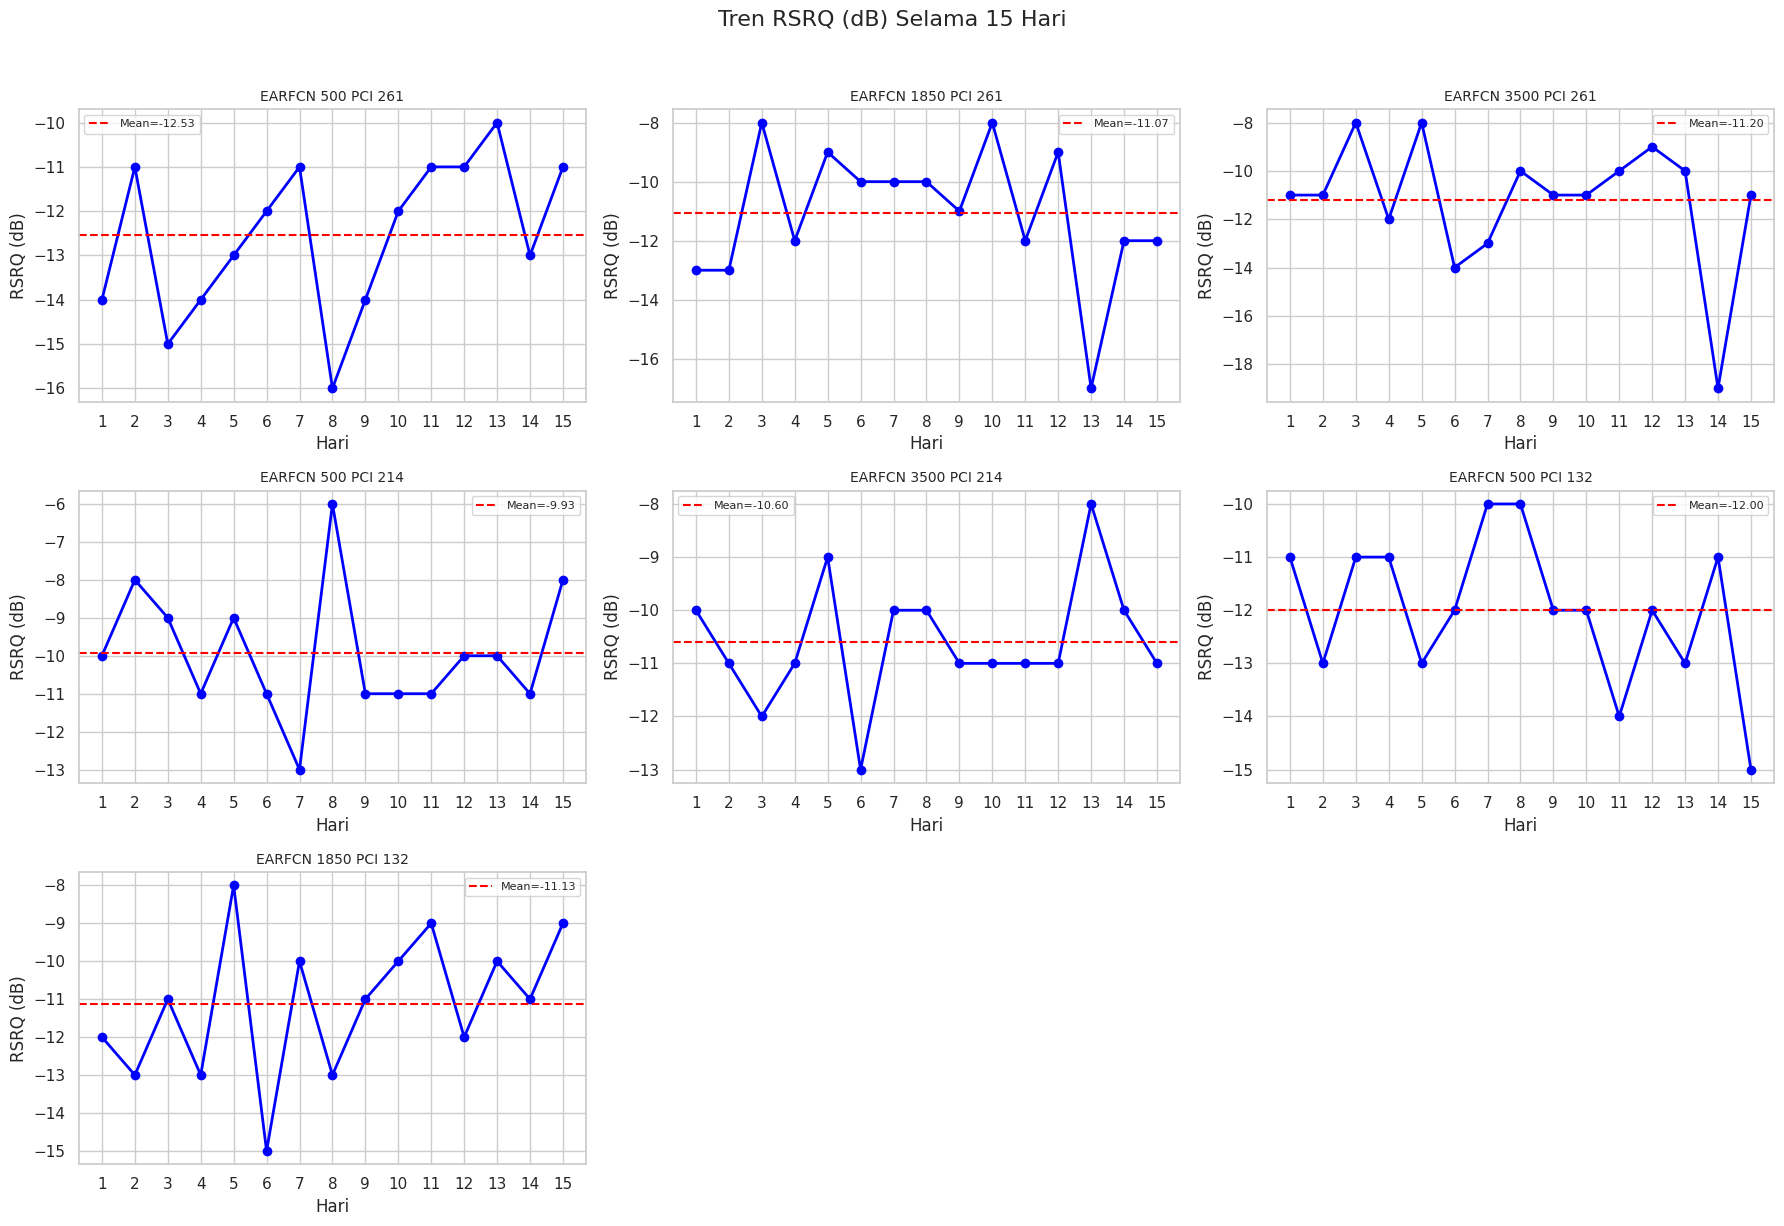

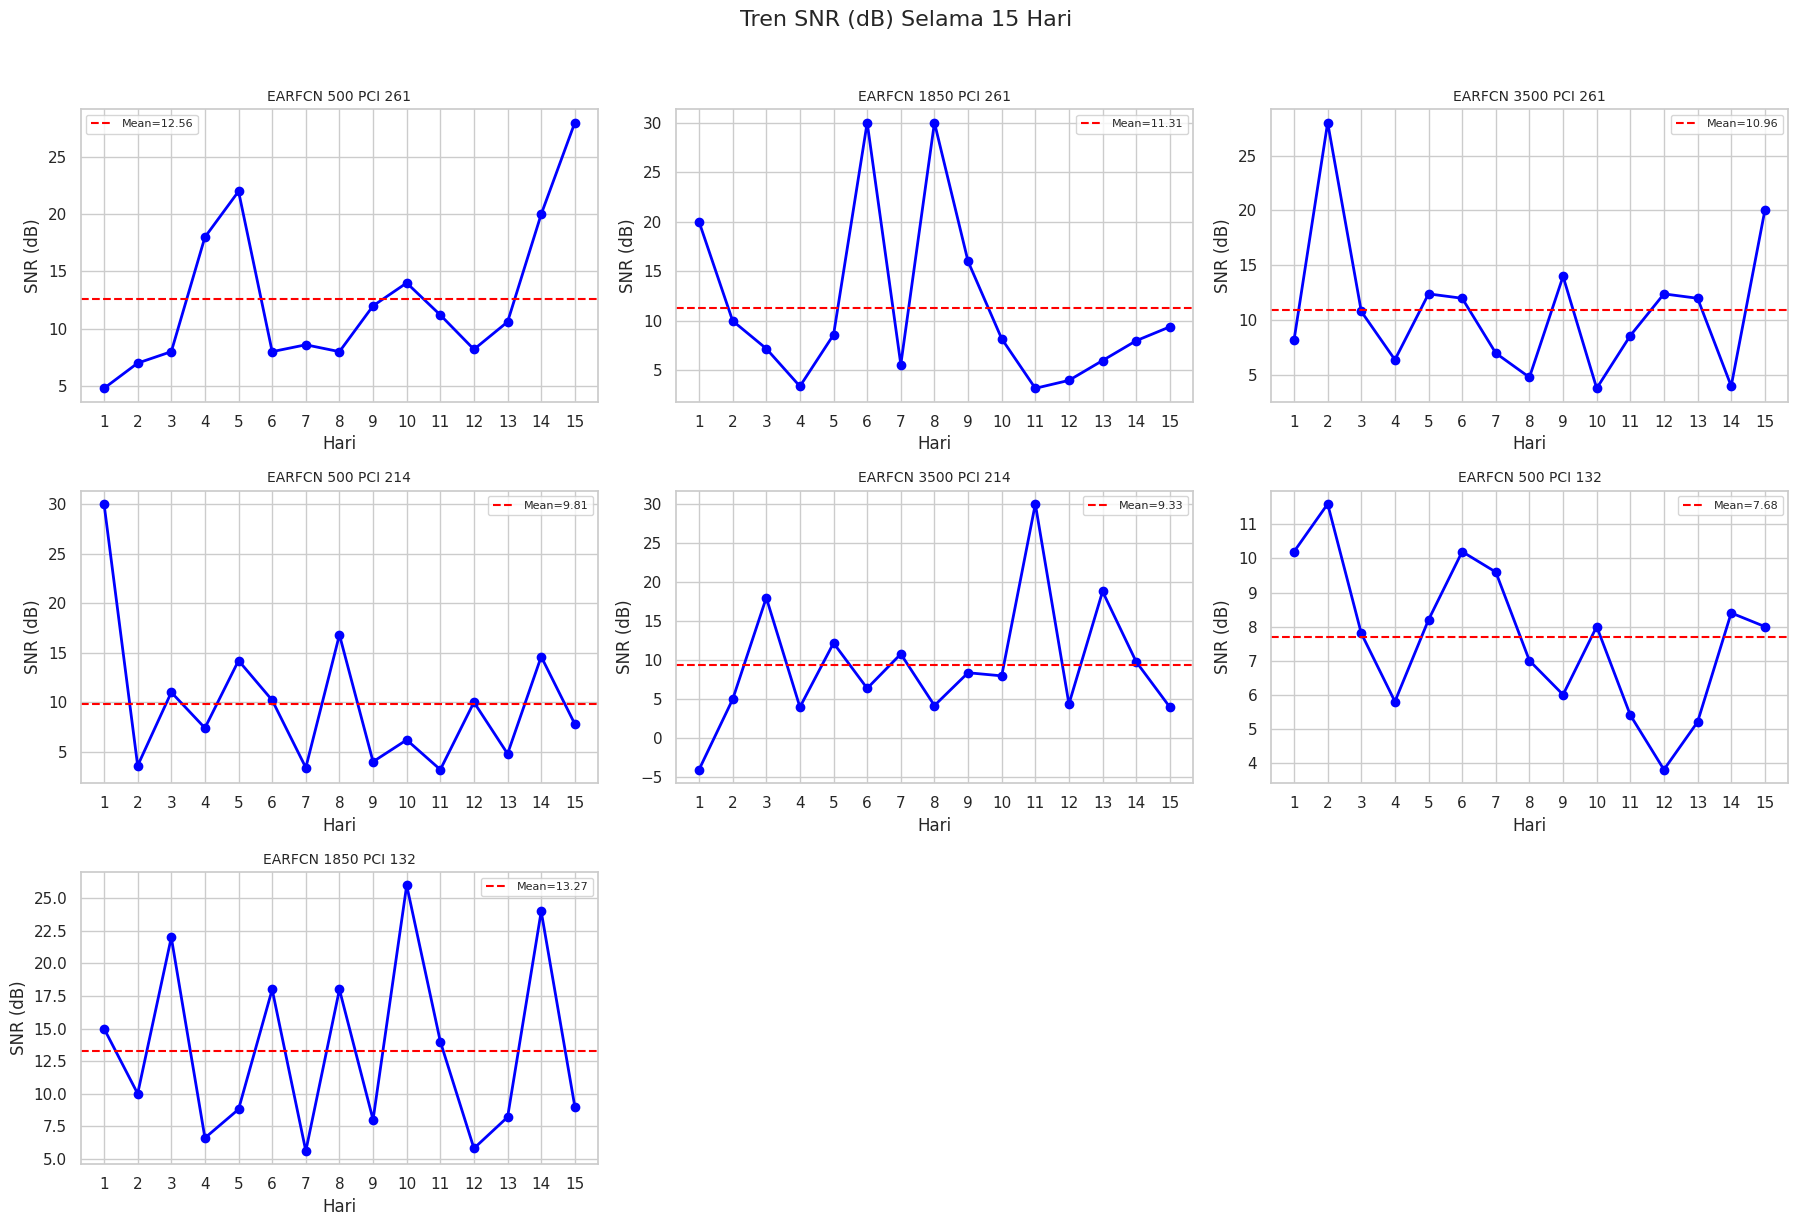

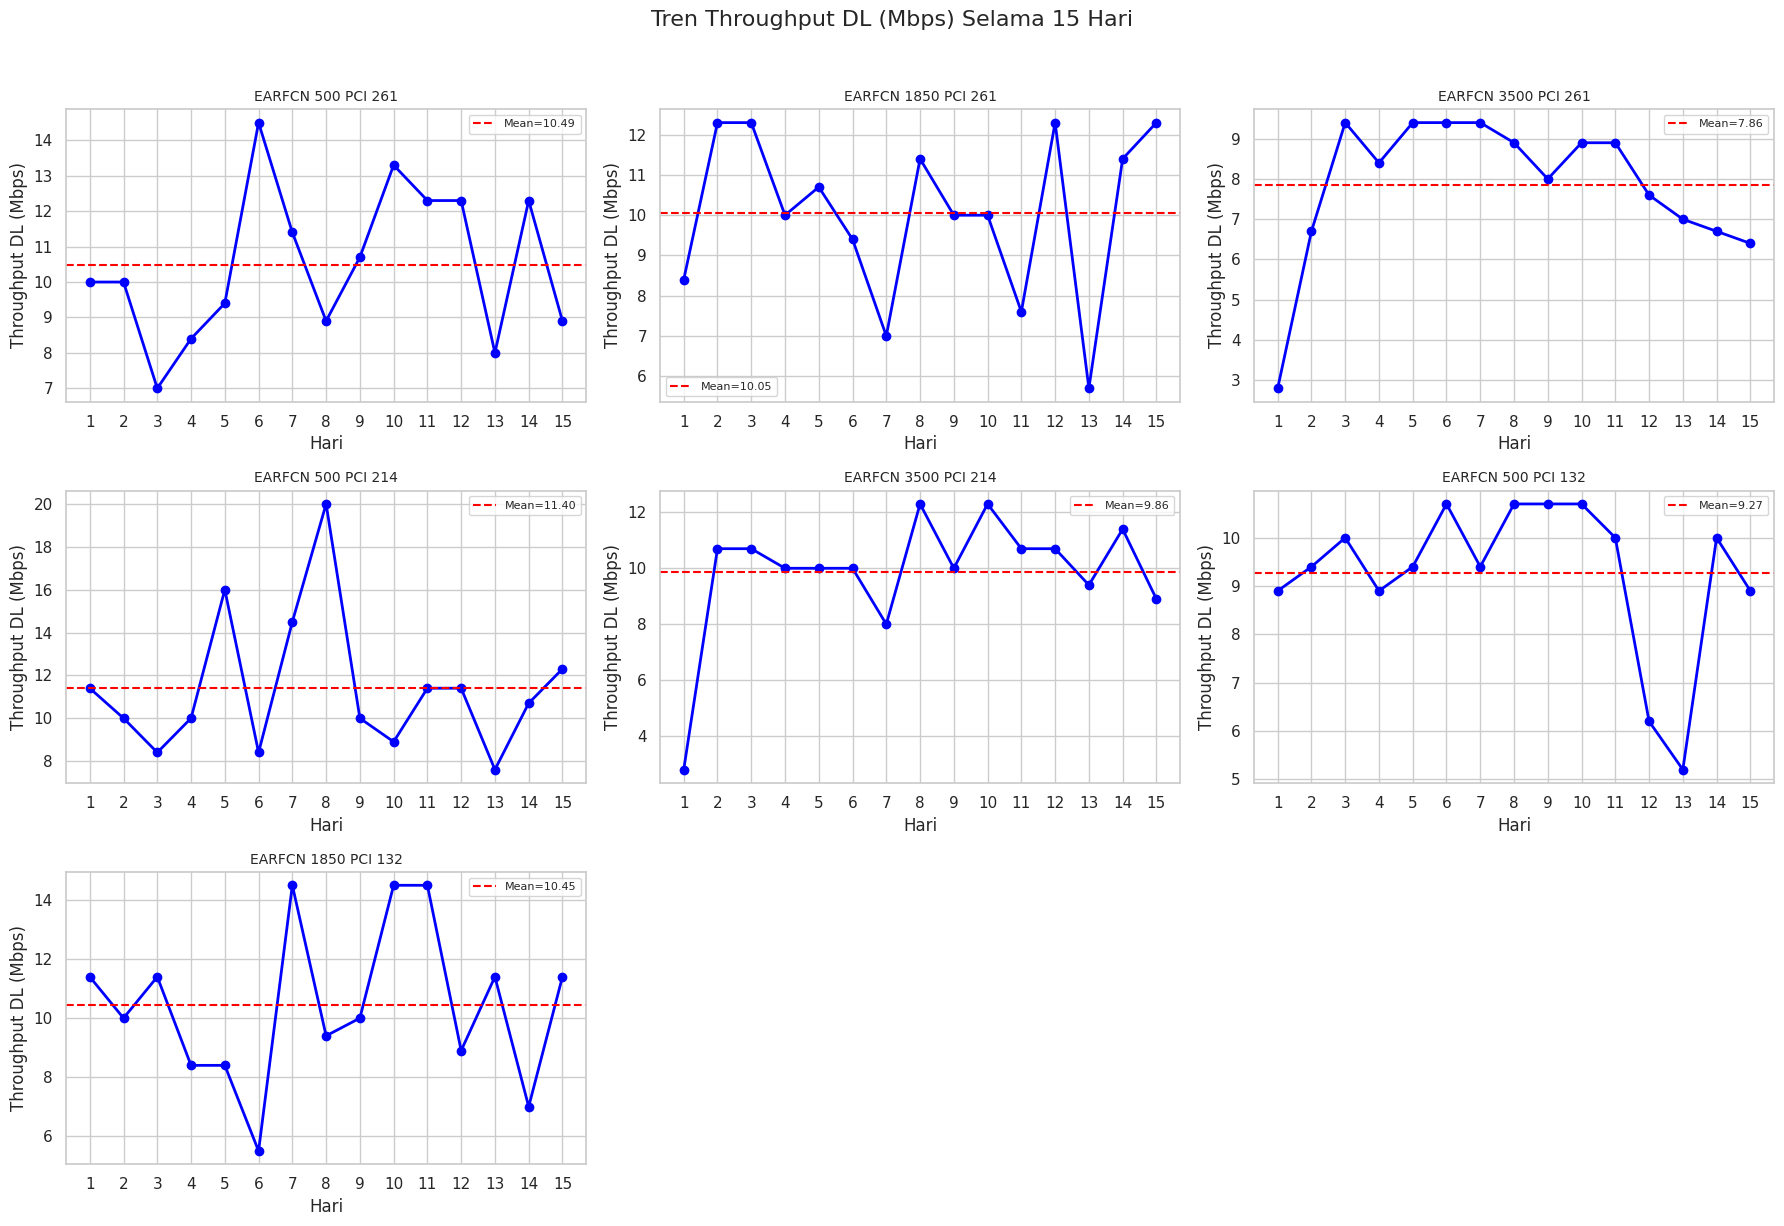

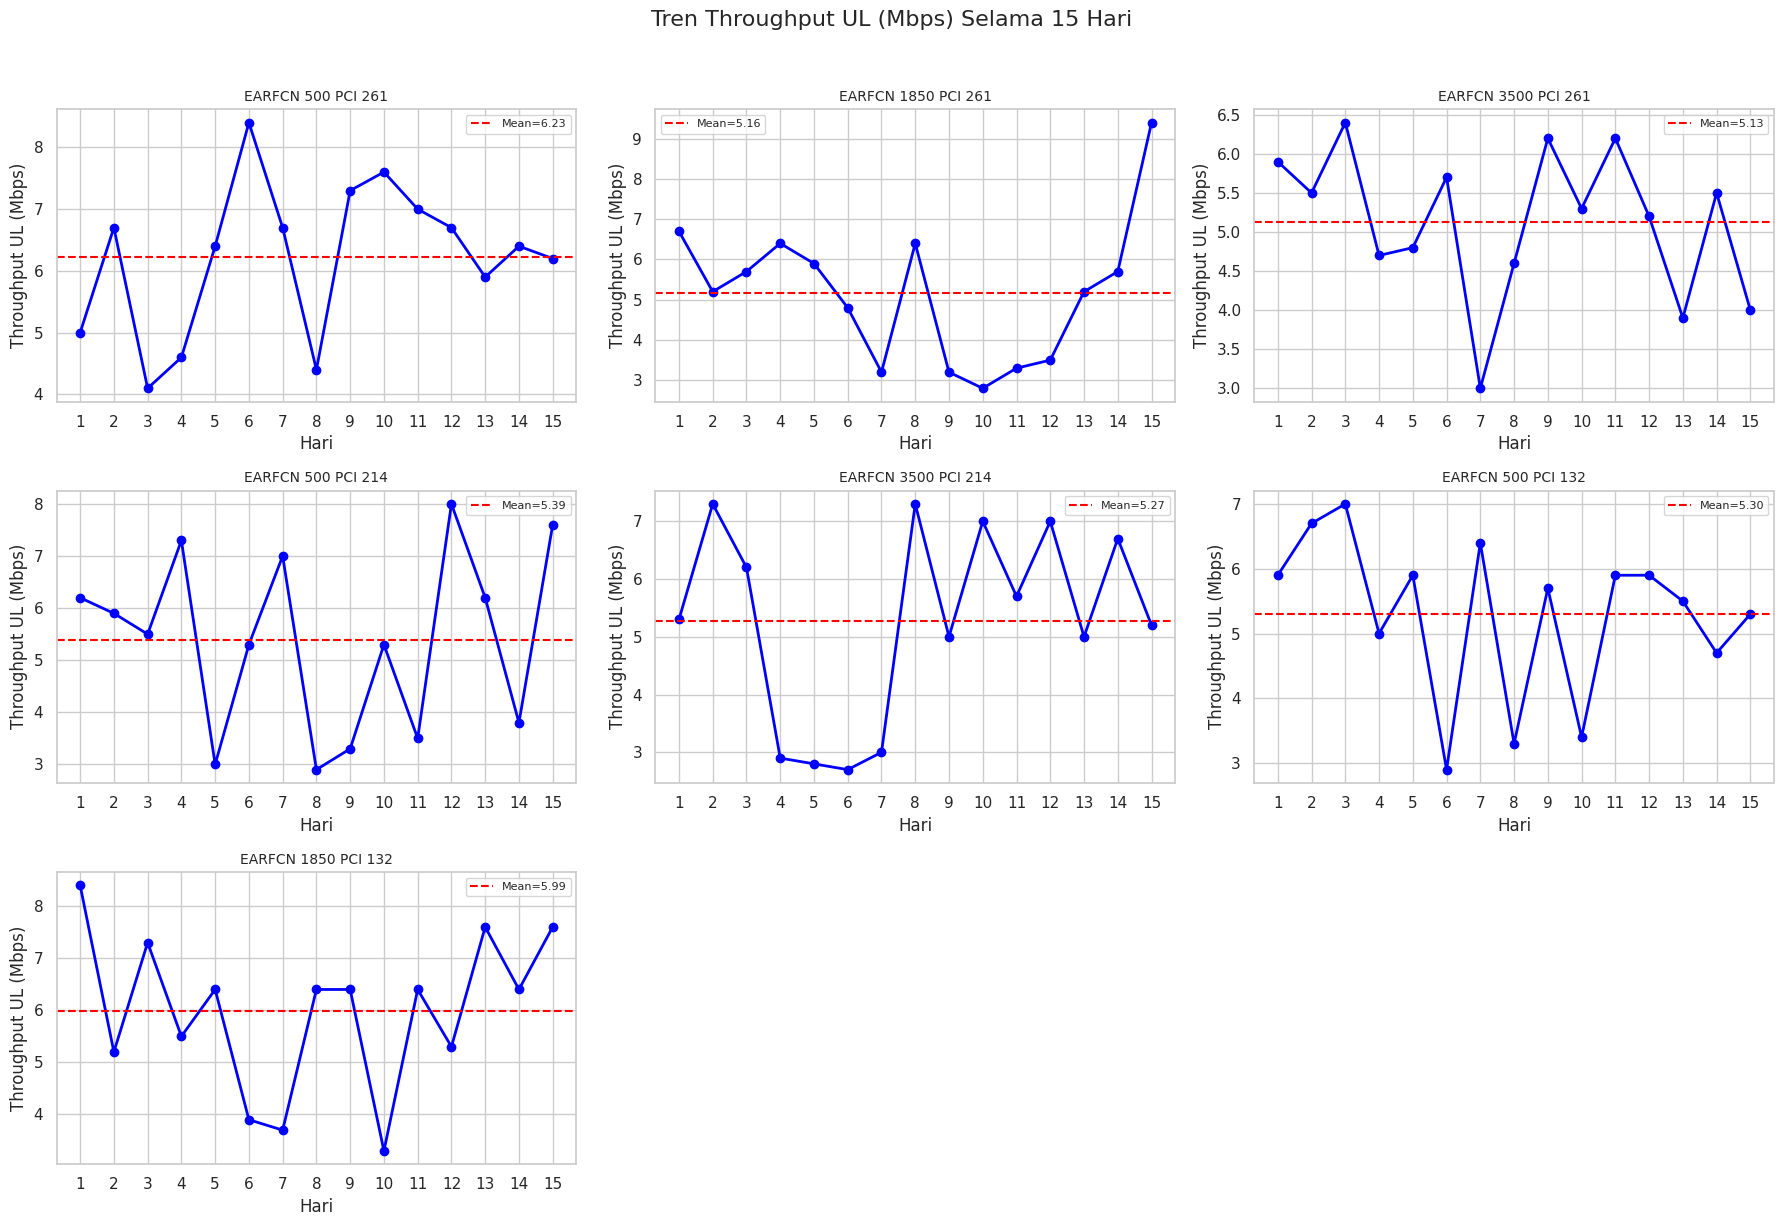

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from google.colab import files

sns.set(style="whitegrid")

# ============================================
# UPLOAD FILE EXCEL
# ============================================
uploaded = files.upload()
filename = list(uploaded.keys())[0]

raw = pd.read_excel(filename, header=None)

# ============================================
# CLEANING DATA BLOK HARI 1–15
# ============================================
clean_rows = []
current_day = None

for _, row in raw.iterrows():

    first_cell = str(row[0]).strip() if pd.notna(row[0]) else ''

    day_match = re.match(r'Hari\s*(\d+)', first_cell, re.IGNORECASE)

    if day_match:
        current_day = int(day_match.group(1))
        continue

    if pd.isna(row[2]) or str(row[2]).strip() in ['Skenario (Lock)', '(20 mb)']:
        continue

    clean_rows.append({
        'Hari': current_day,
        'Skenario (Lock)': row[2],
        'RSRP (dBm)': row[6],
        'RSRQ (dB)': row[7],
        'SNR (dB)': row[8],
        'Throughput DL (Mbps)': row[11],
        'Throughput UL (Mbps)': row[12]
    })

df = pd.DataFrame(clean_rows)

# ============================================
# KONVERSI NUMERIK
# ============================================
numeric_cols = [
    'RSRP (dBm)',
    'RSRQ (dB)',
    'SNR (dB)',
    'Throughput DL (Mbps)',
    'Throughput UL (Mbps)'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', '.'),
        errors='coerce'
    )

# ============================================
# PLOT SUBPLOT PER PARAMETER
# ============================================
skenario_list = df['Skenario (Lock)'].unique()

for param in numeric_cols:

    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, skenario in enumerate(skenario_list):

        temp = df[df['Skenario (Lock)'] == skenario].sort_values('Hari')

        mean_val = temp[param].mean()

        axes[i].plot(
            temp['Hari'],
            temp[param],
            marker='o',
            linewidth=2,
            color='blue'
        )

        axes[i].axhline(
            y=mean_val,
            color='red',
            linestyle='--',
            linewidth=1.5,
            label=f'Mean={mean_val:.2f}'
        )

        axes[i].set_title(skenario, fontsize=10)
        axes[i].set_xlabel('Hari')
        axes[i].set_ylabel(param)
        axes[i].set_xticks(range(1,16))
        axes[i].grid(True)
        axes[i].legend(fontsize=8)

    for j in range(len(skenario_list), 9):
        fig.delaxes(axes[j])

    fig.suptitle(
        f'Tren {param} Selama 15 Hari',
        fontsize=16,
        y=1.02
    )

    plt.tight_layout()
    plt.show()